# Taller 2: Operaciones de transformación del histograma

**Autores:** Estefanía Laverde Becerra, Harvey Benitez Amaya

In [3]:
!pip3 install scikit-image --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [4]:
# librerías 
import cv2
from skimage import exposure

import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Calibración del histograma (o expansión del contraste)

- 1. Cree una nueva sección en su notebook.
- 2. Cargue la imagen de trabajo y visualicela.

In [8]:
# funcion para cargar y visualizar imágenes
def read_and_show_image_gray_scale(image_path:str):
    """
    Lee una imagen en escala de grises y la muestra.
    
    Parámetros:
    image_path (str): Ruta de la imagen a leer.
    
    Retorna:
    image (numpy.ndarray): Imagen leída en escala de grises.
    """

    # leer la imagen
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # mostrar la imagen
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()

    return image

In [9]:
# path a las imágenes
path = 'images/'

# miramos las imagenes del directorio
images = os.listdir(path)
print(images)

['MUSCLE.png', 'ANGIO.png', 'QUITO.png', 'RONDELLE.png', 'BOUGIES.png']


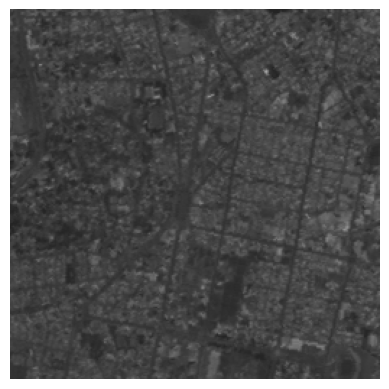

In [12]:
quito_image = read_and_show_image_gray_scale(path + 'QUITO.png')

- 3. Visualice el histograma de la imagen. Describa su forma. ¿Cuáles son los niveles de gris mínimo y máximo? 

In [51]:
# definimos una nueva función que calcula el histograma de una imagen
def calculate_histogram(image:np.ndarray, min_val:int = 0, max_val:int = 255, hist_title:str = "", show:bool = True) -> np.ndarray:
    """
    Calcula el histograma de una imagen en escala de grises, lo normaliza y grafica el resultado.

    Parámetros:
    image (numpy.ndarray): Imagen en escala de grises.
    min_val (int): Valor mínimo para el rango del histograma.
    max_val (int): Valor máximo para el rango del histograma.
    hist_title (str): Título para el gráfico del histograma.

    Retorna:
    histogram (numpy.ndarray): Histograma de la imagen.
    """
    # calcular el histograma
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

    # normalizar el histograma
    histogram = histogram / histogram.sum()
    
    # plotear el histograma
    plt.plot(histogram)
    plt.xlim([min_val-10, max_val+10])
    if hist_title:
        plt.title(hist_title)

    # mostrar si show es True
    if show:
        plt.show()

    return histogram

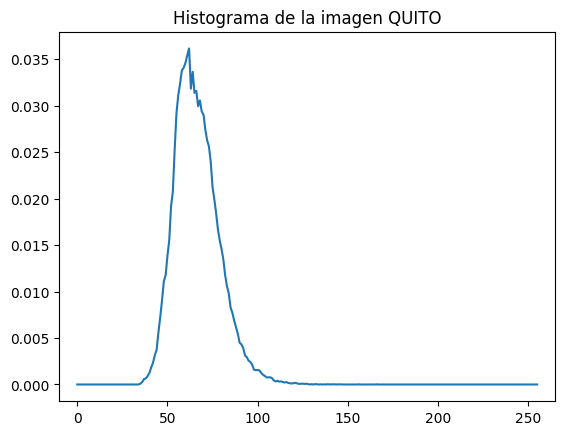

Nivel de gris mínimo: 35
Nivel de gris máximo: 166


In [52]:
# visualizamos el histograma de la imagen
histogram = calculate_histogram(quito_image, hist_title="Histograma de la imagen QUITO")

# pasar la imagen a un vector para calcular minimo y máximo
print(f"Nivel de gris mínimo: {min(quito_image.flatten())}")
print(f"Nivel de gris máximo: {max(quito_image.flatten())}")

La imagen QUITO muestra que la gran mayoría de pixeles tienen valores de grises bajos, entre 40 y 90 aproximadamente, teniendo como valores mínimos 35 y 166. Esto se puede observar en la imagen, donde no hay un buen nivel de contraste y la imagen se ve oscura.

- 4. Efectúe una expansión del contrasete, visualice la imagen resultado y el histograma correspondiente. ¿En qué consiste la mejora de la imagen?

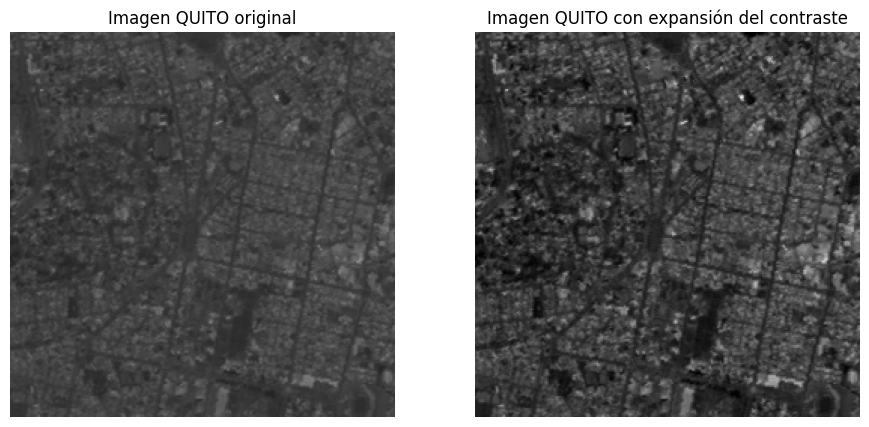

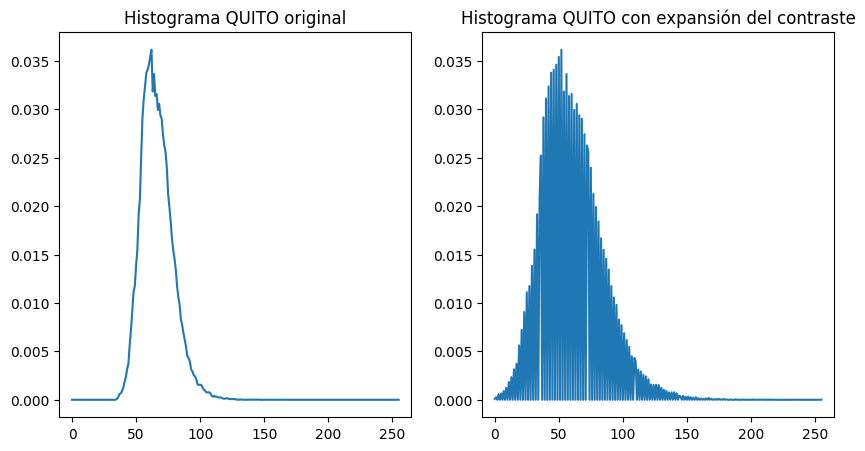

Valor minimo de grises en la imagen con expansión del contraste: 0
Valor maximo de grises en la imagen con expansión del contraste: 255


In [56]:
# expansion del contraste
rescaled_img_quito = exposure.rescale_intensity(quito_image, in_range=(35,166), out_range=(0,255)).astype(np.uint8)

# visualizamos la imagen original al lado de la imagen con expansión del contraste
plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
plt.imshow(quito_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO original")

plt.subplot(1,2,2)
plt.imshow(rescaled_img_quito, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO con expansión del contraste")
plt.show()

# visualizamos el histograma de la imagen resultado
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_original = calculate_histogram(quito_image, hist_title="Histograma QUITO original", show=False)
plt.subplot(1,2,2)
histogram_rescaled = calculate_histogram(rescaled_img_quito, hist_title="Histograma QUITO con expansión del contraste", show=False)
plt.show()

print("Valor minimo de grises en la imagen con expansión del contraste:", min(rescaled_img_quito.flatten()))
print("Valor maximo de grises en la imagen con expansión del contraste:", max(rescaled_img_quito.flatten()))

Al realizar una expansión del contraste, se toman los valores mínimos y máximos de la imagen y se reescalan de forma que el valor mínimo se convierta en 0 y el valor máximo se convierta en 255. Esto mejora la imagen al aumentar el contraste, haciendo que los detalles sean más visibles y la imagen se vea ligeramente más clara. En el histograma, esto se reflejará en una expansión de la distribución de los valores de gris ocupando el rango completo de 0 a 255. Además, aparecen saltos o huecos entre niveles consecutivos ya que el reescalado asigna los nuevos niveles de gris de forma discreta.

- 5. También es posible efectuar una expansión del contraste entre dos valores particulares. Se trata de una transformación lineal del histograma, que permite especificar 2 niveles de gris que deben ser respectivamente llevados a 0 y 255. Esta transformación se llama calibración del histograma.
- 6. Efectúe 3 calibraciones diferentes del histograma sobre la imagen original, entre los valores 50-100, 40-120, 35-166. Visualice los resultados.

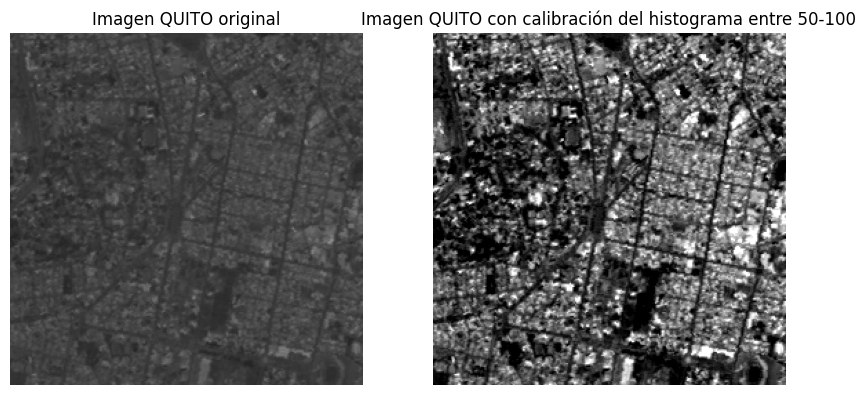

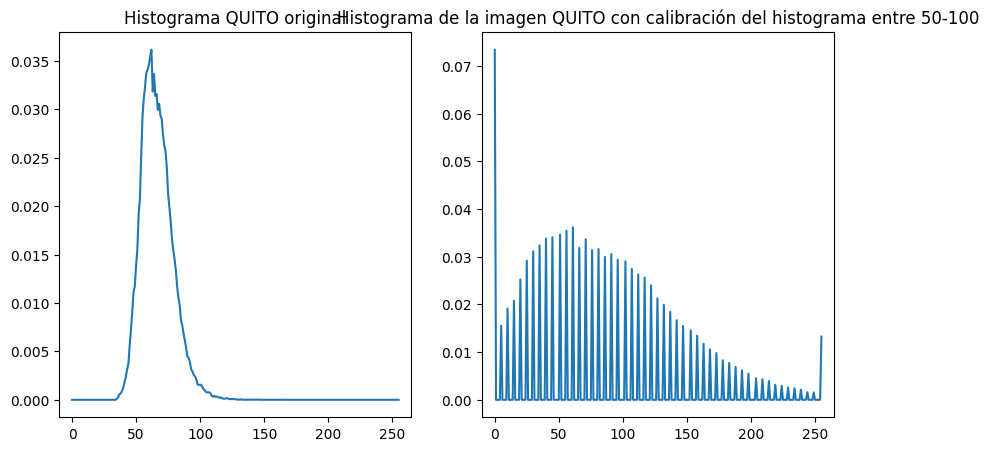

In [58]:
# para la calirbación del histograma, el parámetro in_range se establece con los valores que queremos
rescaled_img_quito = exposure.rescale_intensity(quito_image, in_range=(50,100), out_range=(0,255)).astype(np.uint8)

# visualizamos la imagen original al lado de la imagen con expansión del contraste
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(quito_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO original")

plt.subplot(1,2,2)
plt.imshow(rescaled_img_quito, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO con calibración del histograma entre 50-100")
plt.show()

# visualizamos el histograma de la imagen resultado
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_original = calculate_histogram(quito_image, hist_title="Histograma QUITO original", show=False)
plt.subplot(1,2,2)
histogram_rescaled = calculate_histogram(rescaled_img_quito, hist_title="Histograma de la imagen QUITO con calibración del histograma entre 50-100", show=False)
plt.show()

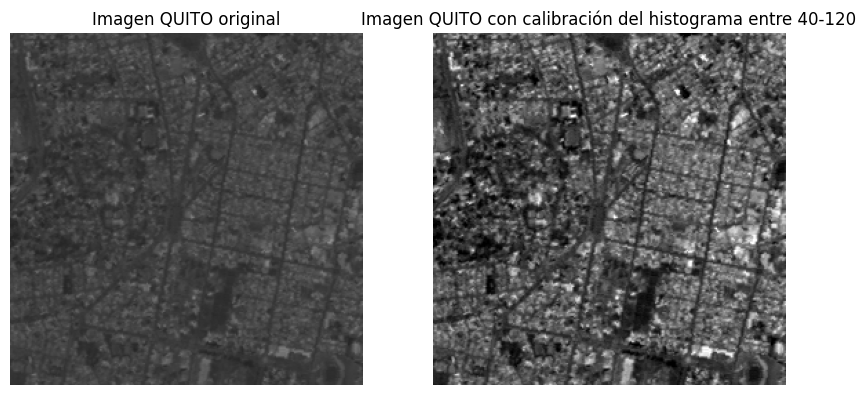

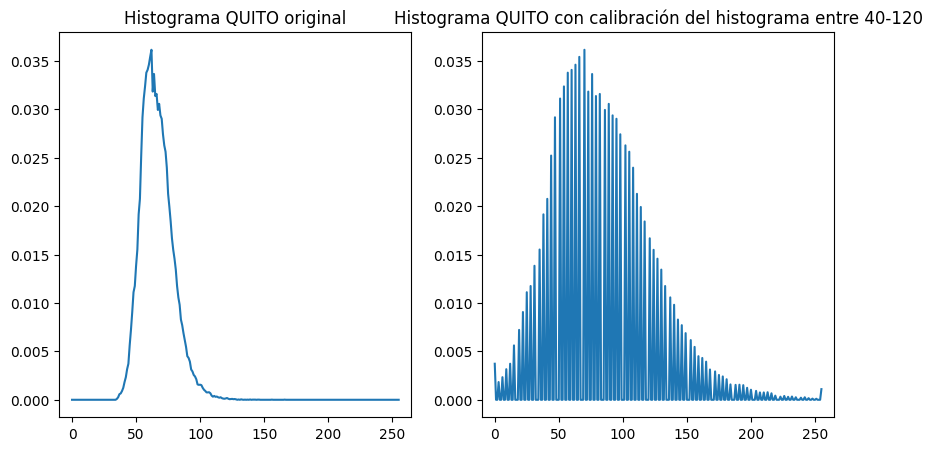

In [57]:
rescaled_img_quito = exposure.rescale_intensity(quito_image, in_range=(40,120), out_range=(0,255)).astype(np.uint8)

# visualizamos la imagen original al lado de la imagen con expansión del contraste
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(quito_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO original")

plt.subplot(1,2,2)
plt.imshow(rescaled_img_quito, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO con calibración del histograma entre 40-120")
plt.show()

# visualizamos el histograma de la imagen resultado
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_original = calculate_histogram(quito_image, hist_title="Histograma QUITO original", show=False)
plt.subplot(1,2,2)
histogram_rescaled = calculate_histogram(rescaled_img_quito, hist_title="Histograma QUITO con calibración del histograma entre 40-120", show=False)
plt.show()

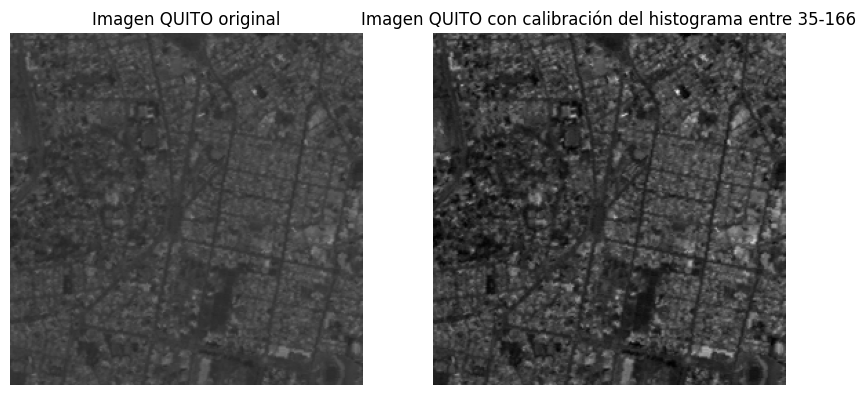

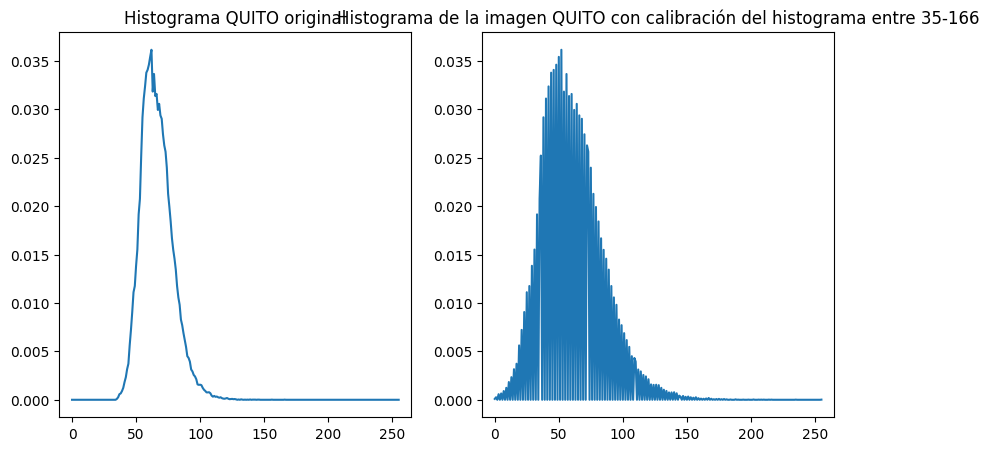

In [59]:
rescaled_img_quito = exposure.rescale_intensity(quito_image, in_range=(35,166), out_range=(0,255)).astype(np.uint8)

# visualizamos la imagen original al lado de la imagen con expansión del contraste
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(quito_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO original")

plt.subplot(1,2,2)
plt.imshow(rescaled_img_quito, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO con calibración del histograma entre 35-166")
plt.show()

# visualizamos el histograma de la imagen resultado
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_original = calculate_histogram(quito_image, hist_title="Histograma QUITO original", show=False)
plt.subplot(1,2,2)
histogram_rescaled = calculate_histogram(rescaled_img_quito, hist_title="Histograma de la imagen QUITO con calibración del histograma entre 35-166", show=False)
plt.show()

- 7. ¿Cuál es la diferencia entre estas imágenes? ¿Cuál presenta el mejor contraste? ¿Cuál permite ver mejor los detalles? ¿Por qué la calibración entre 35 y 166 da el mismo resultado que la expansión del contraste efectuada en el punto 4? ¿Conclusión?

Al modificar los rangos de calibración del histograma se observa que el nivel de contraste de la imagen depende directamente de dichos rangos. Un rango más pequeño (50 a 100) provoca una expansión más agresiva de los niveles de gris, siendo esta la que muestra el mejor contraste, ya que los valores de gris por debajo de 50 se saturan a 0 y los valores por encima de 100 se saturan a 255, incrementando así las diferencias entre intensidades. Sin embargo, esta expansión resulta en una pérdida de detalles en las áreas más oscuras de la imagen. En este sentido, la que permite ver mejor los detalles como calles, parques y edificaciones es la calibración entre 40 y 120, ya que aunque el contraste es menor que en el caso anterior, se preservan más detalles en las áreas oscuras de la imagen. El rango más grande (35 a 166) da el mismo resultado que la expansión del contraste del punto 4 porque estos son exactamente los valores mínimos y máximos de tonalidades en la imagen original, indicando que 35 se mapea a 0 y 166 se mapea a 255, lo que es equivalente a la expansión del contraste realizada en el punto 4.

En conclusión, la calibración del histograma es una gran herramienta cuando se desea mejorar el contraste de una imagen, pero es importante elegir de forma correcta los rangos de calibración para evitar la pérdida de detalles en la imagen.

---

## 2. Ecualización del histograma

- 1. Cree una nueva sección en su notebook.
- 2. Cargue la imagen quito.png y visualicela.

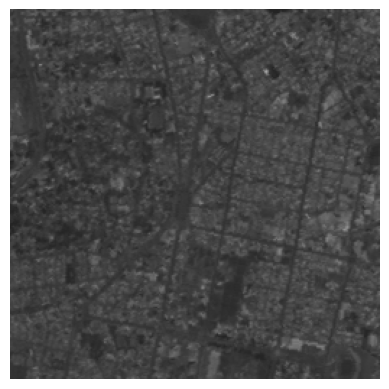

In [34]:
quito_image = read_and_show_image_gray_scale(path + 'QUITO.png')

- 3. Visualice su histograma.

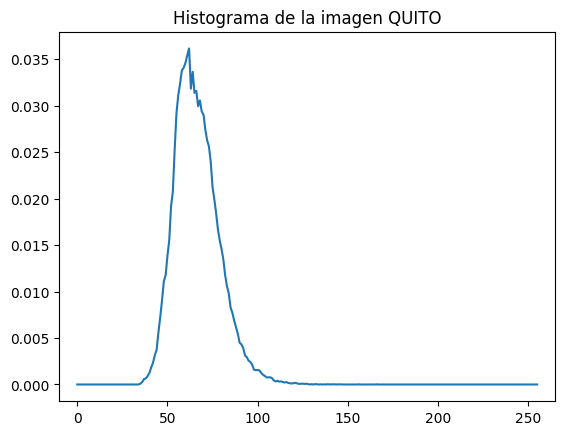

In [35]:
histogram_quito = calculate_histogram(quito_image, hist_title="Histograma de la imagen QUITO")

- 4. Efectúe una ecualización del histograma, visualice la imagen resultado y su histograma. En este caso particualr, ¿a qué se debe la discontinuidad del histograma ecualizado?

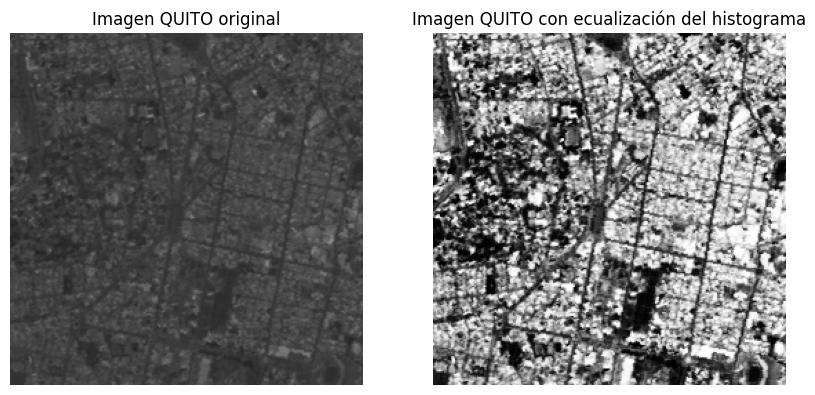

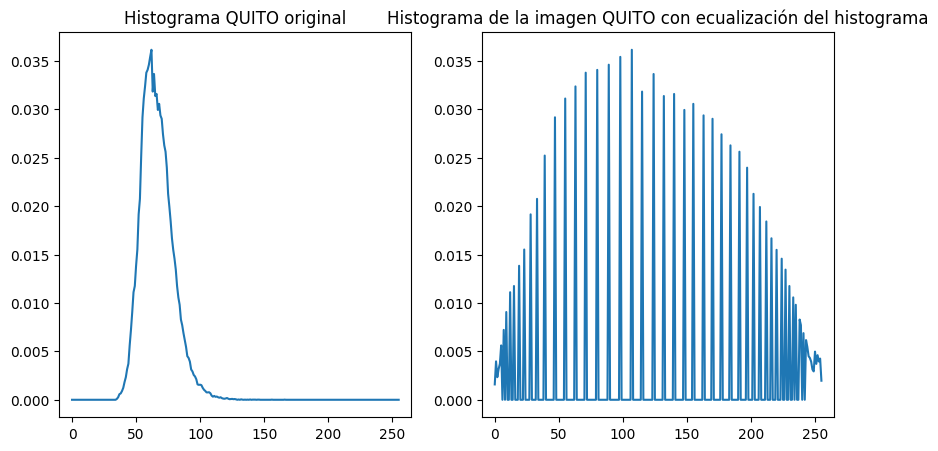

In [60]:
# ecualizar el histograma de la imagen
imagen_equ = cv2.equalizeHist(quito_image)

# visualizamos la imagen original al lado de la imagen con ecualización del histograma
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(quito_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO original")  

plt.subplot(1,2,2)
plt.imshow(imagen_equ, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO con ecualización del histograma")
plt.show()

# visualizamos el histograma de la imagen resultado
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_original = calculate_histogram(quito_image, hist_title="Histograma QUITO original", show=False)
plt.subplot(1,2,2)
histogram_equ = calculate_histogram(imagen_equ, hist_title="Histograma de la imagen QUITO con ecualización del histograma", show=False)
plt.show()

La ecualización del histograma consiste en aplicar una función de transformación monótona creciente a los niveles de gris de la imagen de modo que aproximadamente se tenga la misma probabilidad de aparción para cada nivel de gris. A pesar de que se usa una función monótona creciente, es necesario discretizar los niveles de gris para que tomen valores enteros entre 0 y 255, por lo que  en el histograma ecualizado se puede observar discontinuidades o saltos. Esta operación produce una mejora significativa del contraste de la imagen, haciendo que los detalles sean más visibles.

- 5. Efectúe una segunda vez esta operación. es decir, aplique una ecualización del histograma a la imagen resultado del punto anterior. ¿Qué pasa? ¿Por qué?

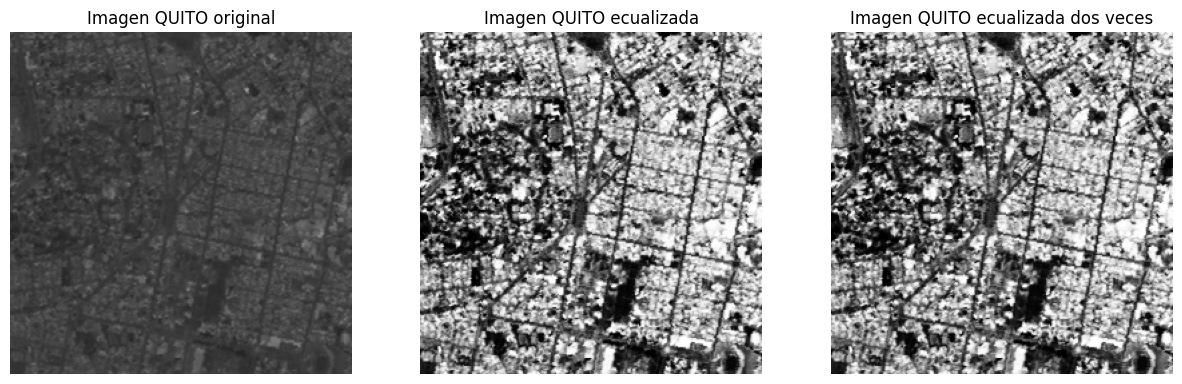

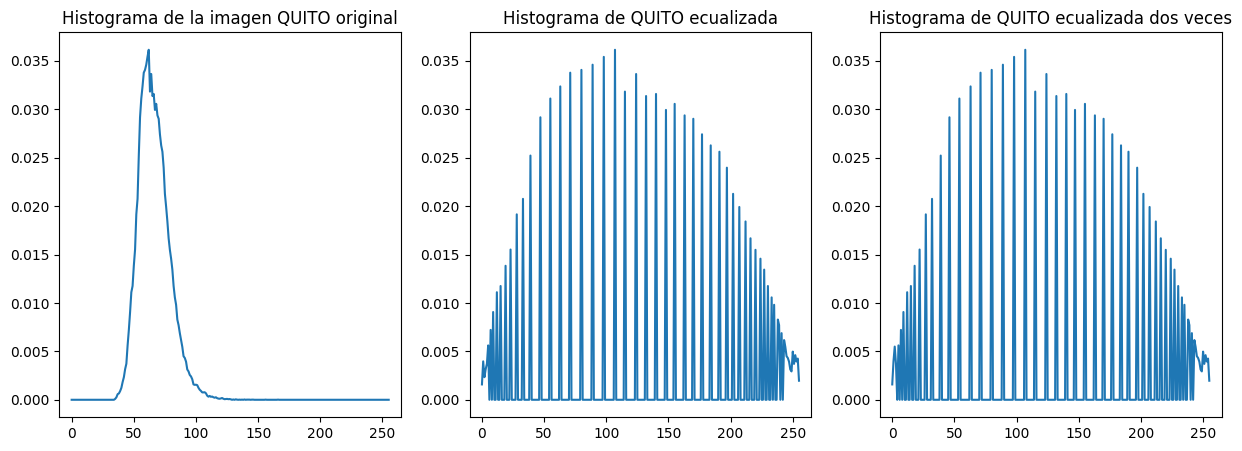

In [61]:
# ecualizar el histograma de la imagen
imagen_equ = cv2.equalizeHist(quito_image)
imagen_equ2 = cv2.equalizeHist(imagen_equ)

# visualizamos la imagen original al lado de la imagen con ecualización del histograma y la imagen con ecualización del histograma aplicada dos veces
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(quito_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO original")  

plt.subplot(1,3,2)
plt.imshow(imagen_equ, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO ecualizada")

plt.subplot(1,3,3)
plt.imshow(imagen_equ2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen QUITO ecualizada dos veces")
plt.show()

# visualizamos el histograma de la imagen resultado
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
histogram_quito = calculate_histogram(quito_image, hist_title="Histograma de la imagen QUITO original", show=False)
plt.subplot(1,3,2)
histogram_equ = calculate_histogram(imagen_equ, hist_title="Histograma de QUITO ecualizada", show=False)
plt.subplot(1,3,3)
histogram_equ2 = calculate_histogram(imagen_equ2, hist_title="Histograma de QUITO ecualizada dos veces", show=False)
plt.show()

Podemos observar que al aplicar una segunda ecualización del histograma a la imagen resultado del punto anterior, no se producen cambios significativos en la imagen ni en el histograma. Esto se debe a que la primera ecualización ya ha distribuido los niveles de gris de manera uniforme, por lo que aplicar una segunda ecualización no tiene un efecto adicional sobre la imagen.

- 6. Repita las operaciones de 1 a 4 con la imagen baboon.png. ¿Cómo es el resultado de esta transformación comparado con la ecualización de la imagen precedente (quito.png)? ¿Por qué?

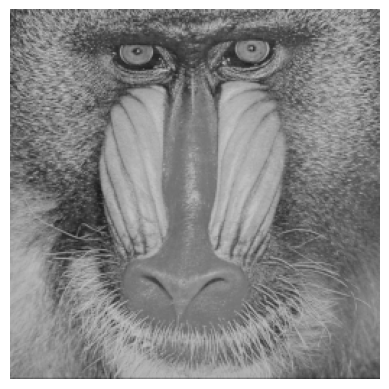

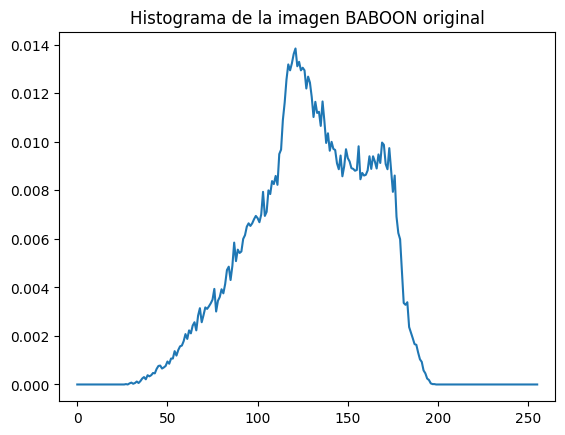

Valor de gris mínimo en la imagen BABOON original: 27
Valor de gris máximo en la imagen BABOON original: 198


In [50]:
baboon_image = read_and_show_image_gray_scale(path + 'BABOON.png')
baboon_histogram = calculate_histogram(baboon_image, hist_title="Histograma de la imagen BABOON original")

print(f"Valor de gris mínimo en la imagen BABOON original: {min(baboon_image.flatten())}")
print(f"Valor de gris máximo en la imagen BABOON original: {max(baboon_image.flatten())}")

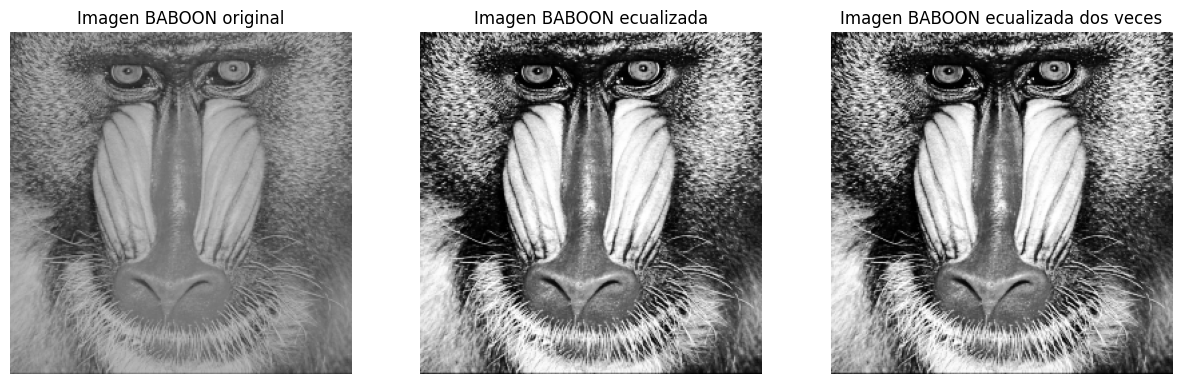

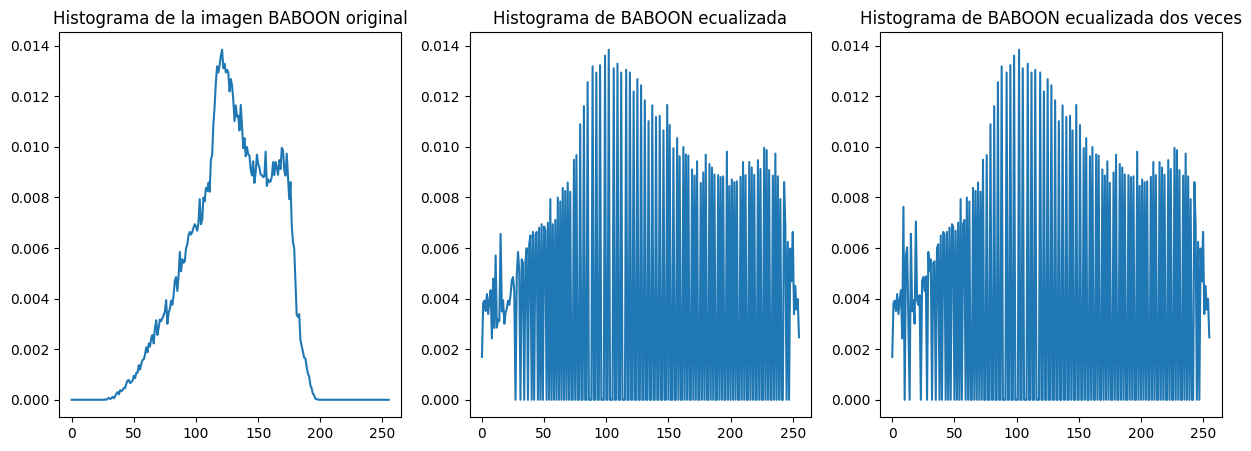

In [63]:
# ecualizar el histograma de la imagen
imagen_equ = cv2.equalizeHist(baboon_image)
imagen_equ2 = cv2.equalizeHist(imagen_equ)

# visualizamos la imagen original al lado de la imagen con ecualización del histograma y la imagen con ecualización del histograma aplicada dos veces
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(baboon_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BABOON original")  

plt.subplot(1,3,2)
plt.imshow(imagen_equ, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BABOON ecualizada")

plt.subplot(1,3,3)
plt.imshow(imagen_equ2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BABOON ecualizada dos veces")
plt.show()

# visualizamos el histograma de la imagen resultado
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
histogram_baboon = calculate_histogram(baboon_image, hist_title="Histograma de la imagen BABOON original", show=False)
plt.subplot(1,3,2)
histogram_equ = calculate_histogram(imagen_equ, hist_title="Histograma de BABOON ecualizada", show=False)
plt.subplot(1,3,3)
histogram_equ2 = calculate_histogram(imagen_equ2, hist_title="Histograma de BABOON ecualizada dos veces", show=False)
plt.show()


La imagen BABOON presenta un rango más amplio de niveles de gris, aproximadamente entre 27 y 198, con una mayor concentración en valores intermedios. En general, muestra una distribución de tonalidades más dispersa que la imagen QUITO, lo que indica una mayor variabilidad de intensidades desde el inicio.

La ecualización del histograma en esta imagen mejora el contraste y permite resaltar con mayor claridad los detalles en las facciones del babuino. En los histogramas se observa una distribución más uniforme de los niveles de gris en comparación con la imagen QUITO, con discontinuidades menos pronunciadas, aunque todavía presentes debido a la discretización del proceso.

Al aplicar la ecualización por segunda vez, se detectan ligeras variaciones en los niveles de gris más oscuros, aproximadamente entre 0 y 30. Sin embargo, estos cambios no se perciben como un gran cambio entre las imagenes de ambas ecualizaciones.

Al comparar ambas imágenes, se observa que el aumento de contraste en BABOON es menos drástico que en QUITO, lo cual se debe a la mejor distribución inicial de los niveles de gris. No obstante, en ambos casos la ecualización del histograma contribuye significativamente a mejorar la visualización de detalles.

---

## 3. Comparación entre diferentes transformaciones del histograma

- 1. Cree una nueva sección en su notebook.
- 2. Cargue la imagen de trabajo y visualicela.

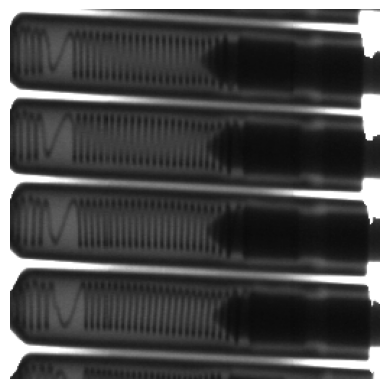

In [64]:
bougies_image = read_and_show_image_gray_scale(path + 'BOUGIES.png')

- 3. Visualice su histograma.

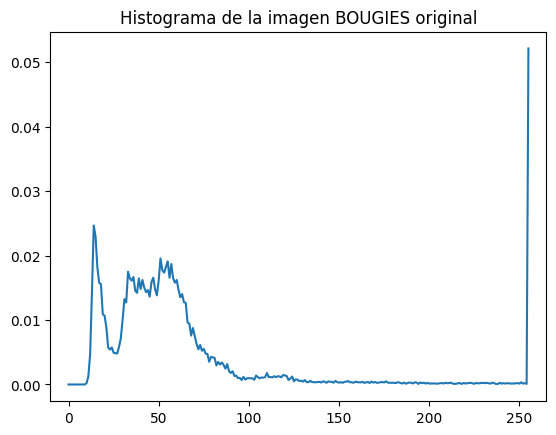

In [65]:
bougies_histogram = calculate_histogram(bougies_image, hist_title="Histograma de la imagen BOUGIES original", show=True)

- 4. Efectúe una expansión del contraste, visualice la imagen resultado y su histograma. Compare las imagenes (original y después de la expansión) junto con sus histogramas. ¿A qué se debe este resultado?

Valores minimos y máximos de BOUGIES: (np.uint8(10), np.uint8(255))


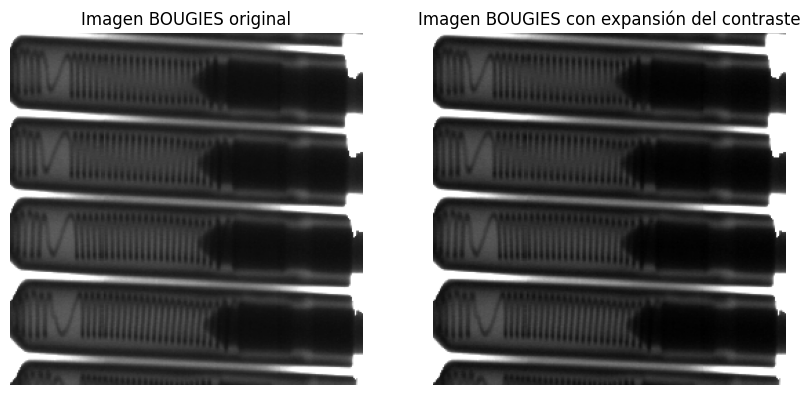

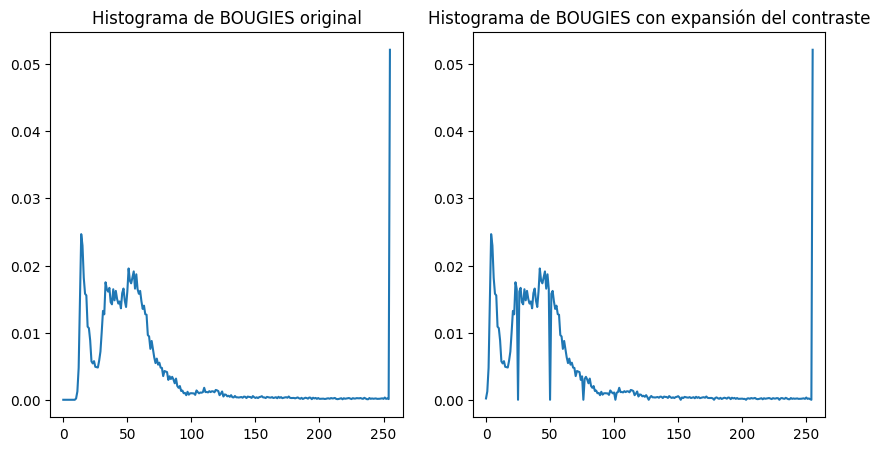

In [69]:
# expansión del contraste
rescaled_img_bougies = exposure.rescale_intensity(bougies_image, in_range=(bougies_image.flatten().min(),bougies_image.flatten().max()), out_range=(0,255)).astype(np.uint8)
print("Valores minimos y máximos de BOUGIES:", (min(bougies_image.flatten()), max(bougies_image.flatten())))
# visualización de la imagen original al lado de la imagen con expansión del contraste
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(bougies_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES original")
plt.subplot(1,2,2)
plt.imshow(rescaled_img_bougies, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES con expansión del contraste")
plt.show()

# histogramas
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_bougies = calculate_histogram(bougies_image, hist_title="Histograma de BOUGIES original", show=False)
plt.subplot(1,2,2)
histogram_rescaled_bougies = calculate_histogram(rescaled_img_bougies, hist_title="Histograma de BOUGIES con expansión del contraste", show=False)
plt.show()

Entre la imagen original de BOUGIES y la imagen resultado de la expansión del contraste se observan mínimos cambios en los histogramas, y ninguno fácilmente perceptible en la imagen. Esto se debe a que los valores mínimos y máximos de la imagen original son 10 y 255 respectivamente, lo que indica que la imagen ya tiene un rango casi completo de niveles de gris, por lo que su extensión a 0 y 255 no produce cambios significativos.

- 5. Sobre la imagen original efectúe ahora una ecualización del histograma, visualice la imagen resultado y su histograma. Compare las imagenes resultado de la expansión (punto anterior) y de la ecualización (resultado actual), junto con sus histogramas. Comente sus observaciones.

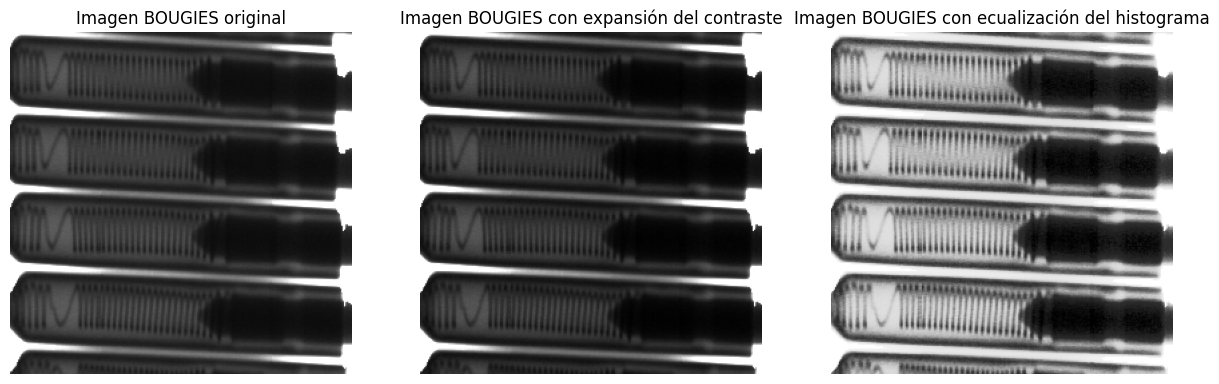

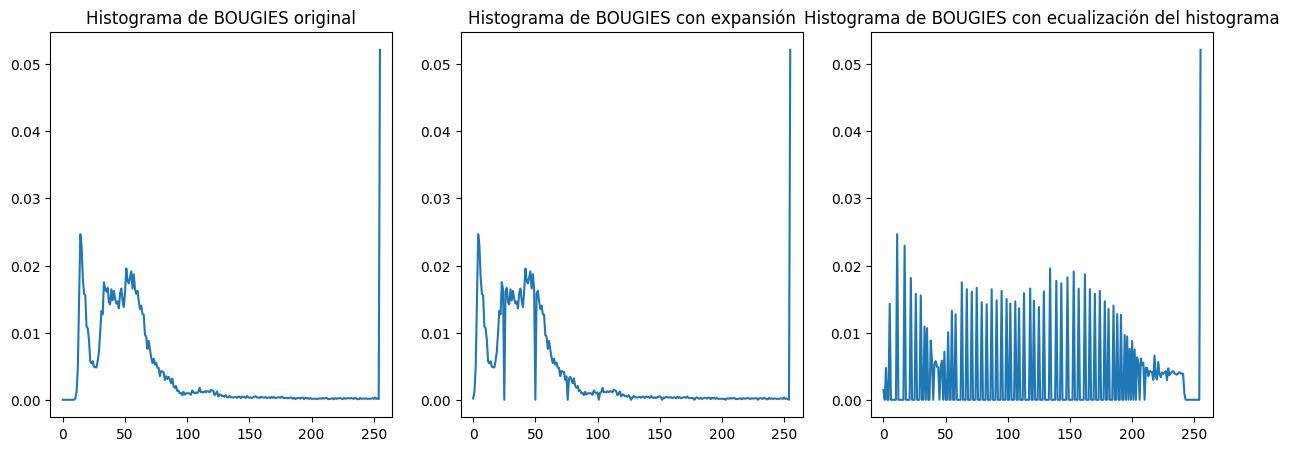

In [71]:
# expansión del contraste
rescaled_img_bougies = exposure.rescale_intensity(bougies_image, in_range=(bougies_image.flatten().min(),bougies_image.flatten().max()), out_range=(0,255)).astype(np.uint8)
# ecualizacion del histograma
equ_img_bougies = cv2.equalizeHist(bougies_image)


# visualización de la imagen original al lado de la imagen con expansión del contraste
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(bougies_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES original")
plt.subplot(1,3,2)
plt.imshow(rescaled_img_bougies, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES con expansión del contraste")
plt.subplot(1,3,3)
plt.imshow(equ_img_bougies, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES con ecualización del histograma")
plt.show()

# histogramas
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
histogram_bougies = calculate_histogram(bougies_image, hist_title="Histograma de BOUGIES original", show=False)
plt.subplot(1,3,2)
histogram_rescaled_bougies = calculate_histogram(rescaled_img_bougies, hist_title="Histograma de BOUGIES con expansión", show=False)
plt.subplot(1,3,3)
histogram_equ_bougies = calculate_histogram(equ_img_bougies, hist_title="Histograma de BOUGIES con ecualización del histograma", show=False)
plt.show()

Comparando los resultados de la ecualización del histograma con la expansión del contraste, observamos que la ecualización sí produce cambios significativos en la image; en la imagen original, hay un pico elevado de valores en blanco y el resto distribuido en niveles de grises bajos, entre 10 y 60 aproximadamente. El resto de valores no cuentan con una gran cantidad de pixeles. Al ecualizar el histograma, comno se busca una distribución más uniforme de los niveles de gris, estos valores en grises bajos se expanden a lo largo del rango completo, lo que resulta en una imagen con un mejor contraste y mayor distinción de detalles (lo que parece un resorte dentro de la imagen se ve con mayor claridad). En el histograma ecualizado se observa en consecuencia una distribución más uniforme de los niveles de gris.

- 6. Sobre la imagen original aplique ahora una transformación logarítmica y multiplique la imagen resultado por un valor constante de 46. ¿Por qué es necesario multiplicar la imagen de salida por un factor? Visualice la imagen resultado y su histograma. ¿Cómo es el histograma resultado?

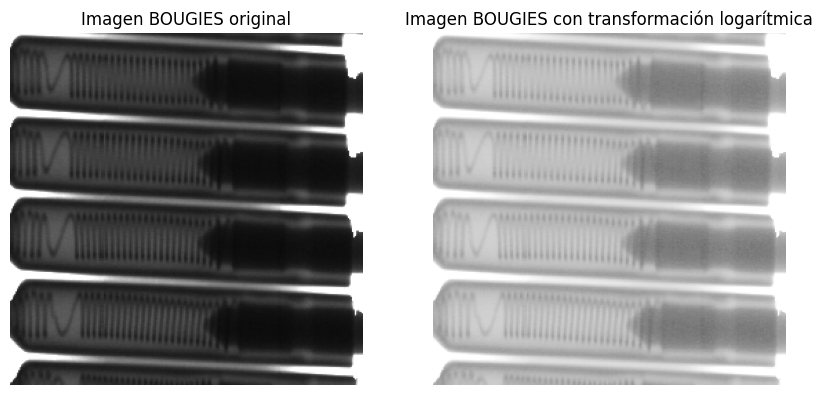

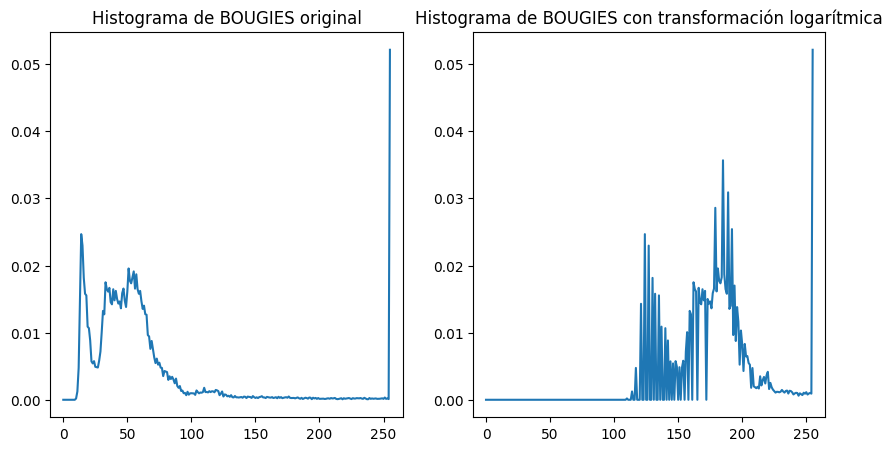

In [88]:
# transformación logarítmica 
# al tener valores en 255 en 8 bits, si sumo 1 van a pasar a ser 0. Convierto la imagen a 16 bits para evitarlo
bougies_image16 = bougies_image.astype(np.uint16)
log_transformed = (np.log(bougies_image16 + 1)) * 46

# visualizacion de la imagen original y la transformada logarítmica
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(bougies_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES original")
plt.subplot(1,2,2)
plt.imshow(log_transformed, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES con transformación logarítmica")
plt.show()

# visualizar histogramas
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_bougies = calculate_histogram(bougies_image, hist_title="Histograma de BOUGIES original", show=False)
plt.subplot(1,2,2)
histogram_log = calculate_histogram(log_transformed, hist_title="Histograma de BOUGIES con transformación logarítmica", show=False)
plt.show()

Al realizar la transformación logarítmica, los valores más bajos de gris se expanden, mientras que los valores más altos se comprimen, es decir, muestran menos diferencia entre ellos. Por ejemplo, el valor 251 se transforma con la aproximación a 52, al igual que 252, perdiendo una tonalidad. El valor máximo al aplicar el logaritmo sería 5.545 aproximadamente, que al multiplicarlo por 46 se obtiene un valor cercano a 255. En este sentido, la multiplicación se hace para escalar los valores de forma que tome aproximadamente todo el rango de grises entre 0 y 255. Esta transformación produce una mejora de contraste en las áreas más oscuras de la imagen. Por esta razón, al ser la imagen BOUGIES una imagen con un rango de grises bastante oscuro, la transformación logarítmica muestra de mejor manera los detalles en las áreas oscuras. En el histograma de resultado se observa entonces una expansión y traslación de los valores grises más oscuros a grises más claros, mientras que los valores altos (claros) tienen una compresión.

- 7. Sobre la imagen original efectúe ahora una especificación de dos histogramas diferentes de entrada. Visualice la imagen resultado, los histogramas esperados y los histogramas obtenidos. Compare los resultados con los de los puntos anteriores. Comente sus observaciones.

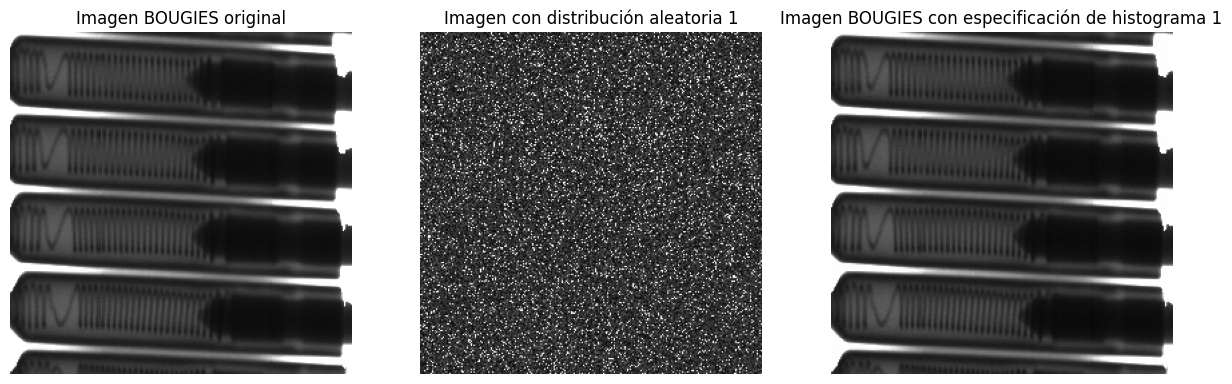

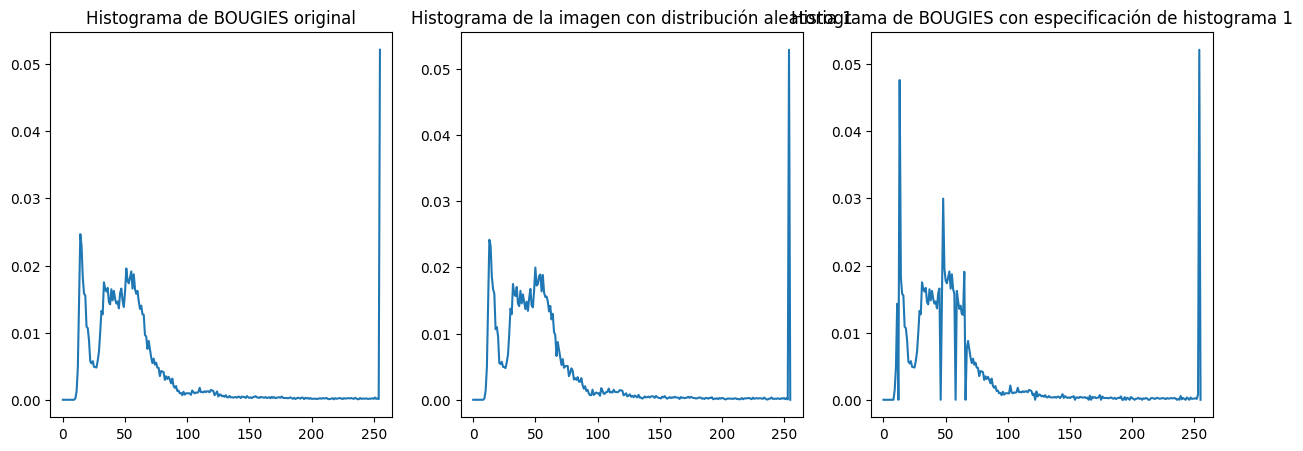

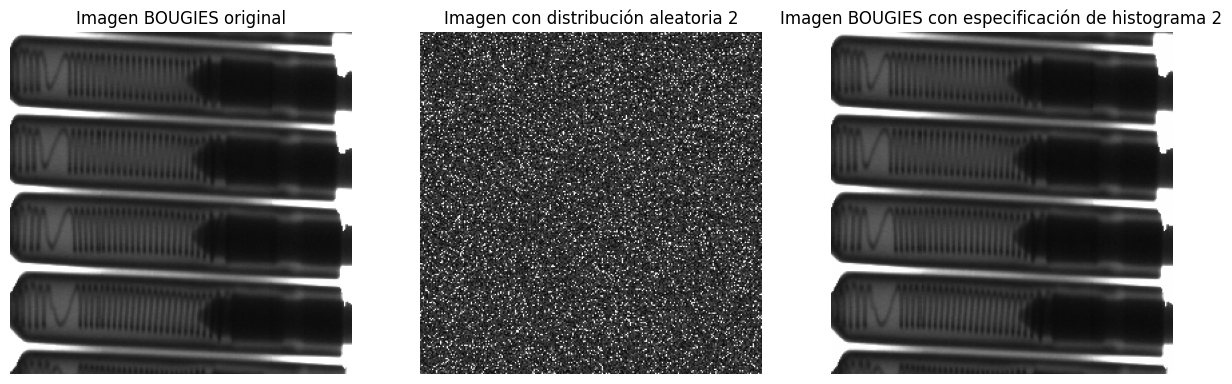

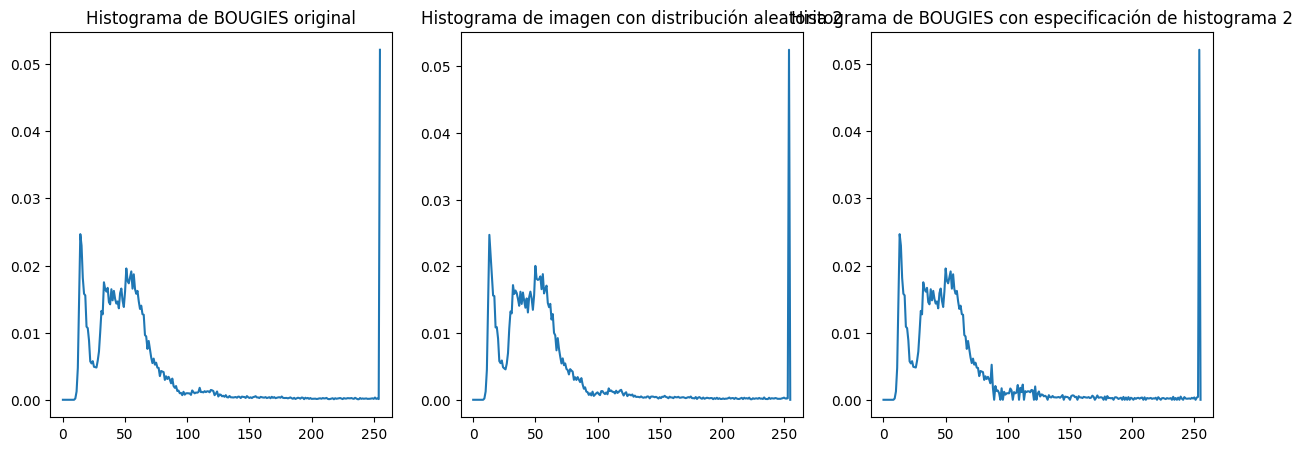

In [126]:
bougies_image = bougies_image.astype(np.uint8)
#Generamos la distribución acumulativa del histograma
cdf = np.cumsum(histogram_bougies)
#Generamos un arreglo con valores aleatorios según la distribución
pixel_values1  = np.interp(np.random.rand(bougies_image.shape[0]*bougies_image.shape[1]), cdf, range(0,256))
#Convertimos el arreglo en una imagen.
i_to_match= pixel_values1.reshape(bougies_image.shape).astype(np.uint8)
matched_image = exposure.match_histograms(bougies_image, i_to_match)
# convertimos a uint8 y cortamos en el rango de 0 a 255
matched_image = np.clip(matched_image, 0, 255).astype(np.uint8)

# Generamos un segundo arreglo aleatorio con la misma distribución
pixel_values2  = np.interp(np.random.rand(bougies_image.shape[0]*bougies_image.shape[1]), cdf, range(0,256))
i_to_match2 = pixel_values2.reshape(bougies_image.shape).astype(np.uint8)
matched_image2 = exposure.match_histograms(bougies_image, i_to_match2)
matched_image2 = np.clip(matched_image2, 0, 255).astype(np.uint8)

# visualizacion de imagenes (original, especificación 1 y especificación 2)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(bougies_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES original")
plt.subplot(1,3,2)
plt.imshow(i_to_match, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen con distribución aleatoria 1")
plt.subplot(1,3,3)
plt.imshow(matched_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES con especificación de histograma 1")
plt.show()

# visualizacion de histogramas
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
histogram_bougies = calculate_histogram(bougies_image, hist_title="Histograma de BOUGIES original", show=False)
plt.subplot(1,3,2)
histogram_random1 = calculate_histogram(i_to_match, hist_title="Histograma de la imagen con distribución aleatoria 1", show=False)
plt.subplot(1,3,3)
histogram_matched1 = calculate_histogram(matched_image, hist_title="Histograma de BOUGIES con especificación de histograma 1", show=False)
plt.show() 

# Mismo procedimiento para la segunda imagen de especificación
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(bougies_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES original")
plt.subplot(1,3,2)
plt.imshow(i_to_match2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen con distribución aleatoria 2")
plt.subplot(1,3,3)
plt.imshow(matched_image2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen BOUGIES con especificación de histograma 2")
plt.show()

# visualizacion de histogramas
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
histogram_bougies = calculate_histogram(bougies_image, hist_title="Histograma de BOUGIES original", show=False)
plt.subplot(1,3,2)
histogram_random2 = calculate_histogram(i_to_match2, hist_title="Histograma de imagen con distribución aleatoria 2", show=False)
plt.subplot(1,3,3)
histogram_matched2 = calculate_histogram(matched_image2, hist_title="Histograma de BOUGIES con especificación de histograma 2", show=False)
plt.show()

El proceso de especificación del histograma ajusta la distribución de intensidades de manera que las tonalidades de la imagen original se asemejen a las de una imagen de referencia. En este caso, al usar la distribución de la imagen BOUGIES como referencia, la imagen aleatoria muestra una distribución de niveles de gris muy similar a la imagen original, teniendo los cambios más significativos en torno a los niveles de gris más altos, cerca a 255. Esto hace que al hacer match con esta imagen, el resultado no cambie mucho con respecto a la imagen original. La efectividad de esta técnica depende entonces de la imagen referencia utilizada, pues si llegan a tener distribuciones parecidas, y no necesariamente imagenes parecidas (como se observa en la imagen aleatoria), los cambios no serán percibidos.


- 8. Haga una comparación entre los tipos de transformaciones ¿Qué impactos tiene cada una? ¿Cómo  pueden ser usadas en el ámbito de mejoramiento de la calidad de la imagen?

Cada tipo de transformación del histograma tiene impactos diferentes en la imagen: la expansión del histograma mejora el contraste de imagenes cuando su distribución de valores de gris se encuentra concentrada en un rango estrecho. La ecualización por su parte ofrece una mejora significativa del contraste al distribuir los niveles de gris de manera uniforme, pero presenta poco control sobre el resultado final. Por otro lado, la transformación logarítmica es especialmente útil para mejorar el contraste en áreas oscuras de la imagen, pero puede resultar en una pérdida de detalles en áreaas claras. Finalmente, la especificación del histograma permite un control más preciso sobre el resultado y más capacidad de adaptación al problema, pero como contraparte, es necesario elegir de forma adecuada la imagen de referencia para obtener resultados satisfactorios.

## 4. Umbralización simple

- 1. Cree una nueva sección en su notebook.
- 2. Cargue la imagen de trabajo **muscle.png** y visualícela.

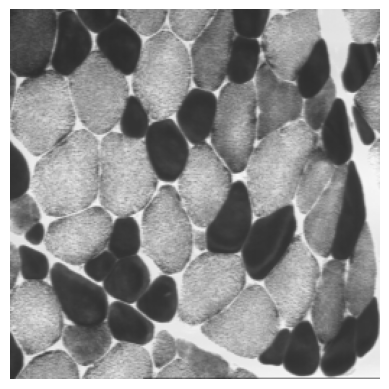

In [127]:
muscle_image = read_and_show_image_gray_scale(path + 'MUSCLE.png')

- 2. Visualice su histograma y escoja un valor $S$ de nivel de gris que permita separar aproximadamente las fibras oscuras del resto de la imagen. ¿Cuál es este valor?

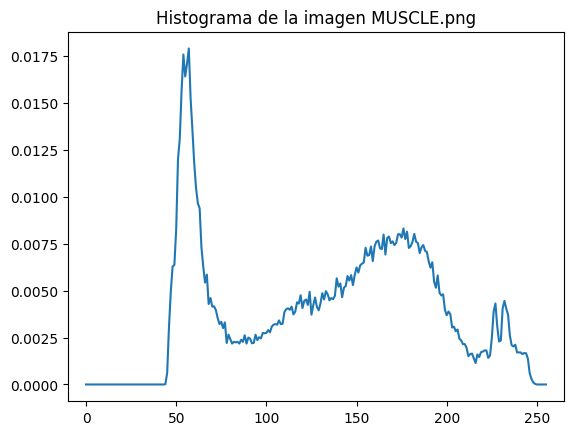

In [128]:
muscle_histogram = calculate_histogram(muscle_image, hist_title="Histograma de la imagen MUSCLE.png")

Las fibras oscuras de la imagen se concentran en el pico de valores bajos del histograma, entre 40 y 90 aproximadamente, por lo que un valor de $S$ adecuado puede ser 85, separando el pico de las firbas oscuras del resto de la imagen.

4. Efectúe una calibración del histograma entre los valores S y S+1 de la imagen. Visualice la imagen resultado y su histograma ¿Cuál es su conclusión?

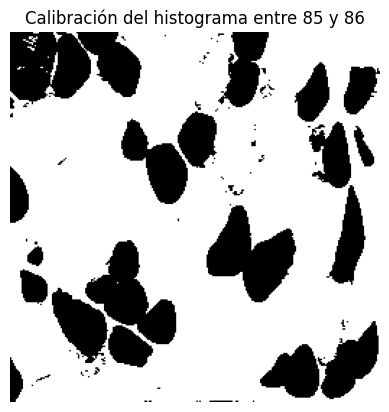

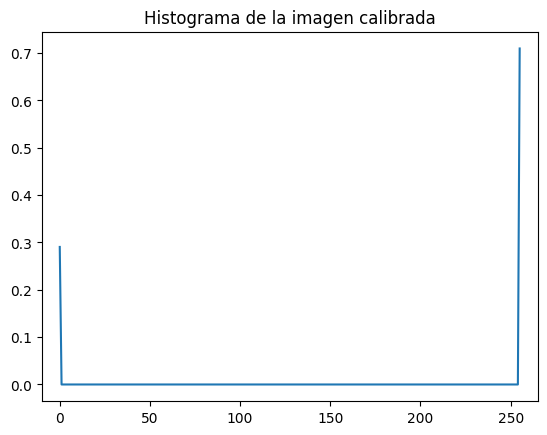

In [129]:
rescaled_img = exposure.rescale_intensity(muscle_image, in_range=(85,86), out_range=(0,255)).astype(np.uint8)

# visualizamos la imagen resultante
plt.imshow(rescaled_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Calibración del histograma entre 85 y 86")
plt.show()

# calculamos y mostramos el histograma de la imagen resultante
rescaled_histogram = calculate_histogram(rescaled_img, hist_title="Histograma de la imagen calibrada")

La calibración del histograma entre los valores S y S+1, es decir entre 85 y 86 está mapeando todos los valores menores a 85 a 0, y todos los valores mayores a 86 a 255, sin tomar ningún otro valor puesto a que no hay valores entre 85 y 86 al ser la imagen discreta. Esto hace que la imagen resultado sea una imagen binaria, donde las fibras oscuras se vean completamente negras en un fondo blanco. De esta misma manera, en el histograma se observa que solo hay dos niveles de gris, 0 y 255.

- 5. Repita la misma operación utilizando el módulo de umbralización simple, con el umbral S. ¿Conclusión?

Valor de umbral utilizado: 85.0


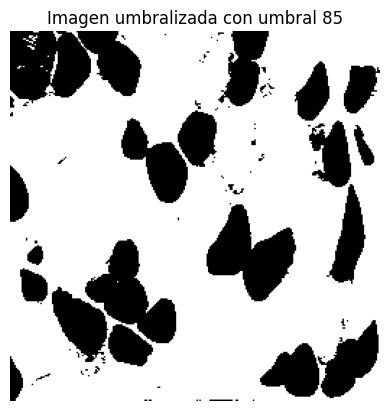

In [34]:
thres_value, thres_image = cv2.threshold(muscle_image, 85, 255, cv2.THRESH_BINARY)

print(f"Valor de umbral utilizado: {thres_value}")

# visualizamos la imagen resultante
plt.imshow(thres_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen umbralizada con umbral 85")
plt.show()

Al realizar una umbralización simple con el umbral S se obtiene exactamente el mismo resultado que con la calibración del histograma entre S y S+1. Esto es debido a que la umbralicación simple es una técnica de segmentación que asigna el valor 0 a los pixeles con valor menor o igual a S y 1 a los pixeles con valor mayor a S.

- 6. ¿Qué resultado dan los métodos de umbralización automática basados sobre la varianza? ¿Cómo eligen estos métodos el umbral a aplicar? Visualice las imágenes resultado y sus histogramas.


Valor de umbral automático (Otsu): 125.0


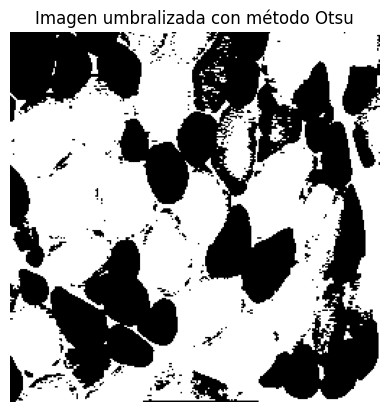

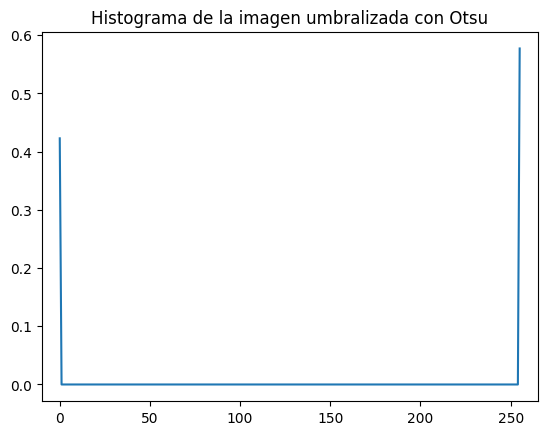

In [35]:
# umbralización automática con método Otsu
otsu_value, otsu_image = cv2.threshold(muscle_image, 0, 255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Valor de umbral automático (Otsu): {otsu_value}")

# visualizamos la imagen resultante
plt.imshow(otsu_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen umbralizada con método Otsu")
plt.show()

# visualizamos el histograma de la imagen umbralizada con Otsu
otsu_histogram = calculate_histogram(otsu_image, hist_title="Histograma de la imagen umbralizada con Otsu")

El método Otsu elige de manera automática el umbral a aplicar basandose en la varianza de los niveles de gris. La idea principal es separar dos clases de pixeles de tal manera que la varianza entre elementos de la misma clase sea mínima, y la varianza entre elementos de distintas clases sea máxima. En este caso, el método Otsu elige un umbral de 125, separando tanto las fibras oscuras como un poco de ruido en otras fibras grises. En contraste, la umbralización simple con el umbral S=85 funciona de manera más eficiente para separar las fibras oscuras del resto de la imagen, con la contraparte de tener que ser un umbral elegido de forma manual.

---

## 5. Umbralización doble

- 1. Cree una nueva sección en su notebook.
- 2. Cargue y visualice las imágenes de trabajo **rondelle.png** y **angio.png**

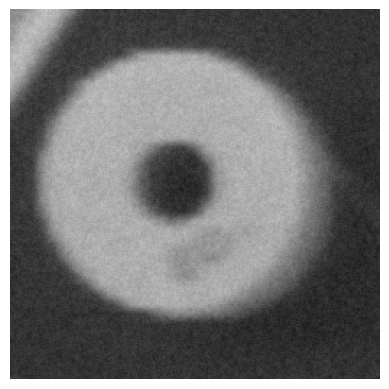

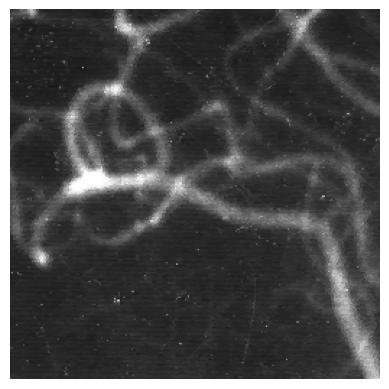

In [134]:
# cargar y visualizar las imágenes
rondelle_image = read_and_show_image_gray_scale(path + 'rondelle.png')
angio_image = read_and_show_image_gray_scale(path + 'angio.png')

- 3. Se desea aplicar una umbralización doble de tal manera que la imagen resultante debe contener tres clases, cuyos niveles de gris son 0, 128 y 255 respectivamente. Para esto, debe utilizar las funciones de umbralización simple y umbralización doble.

In [149]:
def umbral_tres_clases(image:np.ndarray, low_threshold:int, high_threshold:int, clases:tuple=(0,128,255)) -> np.ndarray:
    """
    Aplica una umbralización doble a una imagen para segmentarla en tres clases.

    Parámetros:
    image (numpy.ndarray): Imagen en escala de grises.
    low_threshold (int): Umbral inferior.
    high_threshold (int): Umbral superior.
    clases (tuple): Niveles de gris para las tres clases.

    Retorna:
    result_image (numpy.ndarray): Imagen segmentada en tres clases.
    """
    # umbralización doble para obtener la region entre los umbrales
    img_middle = cv2.inRange(image, low_threshold, high_threshold)
    # umbral sencillo para obtener la región por encima del umbral superior
    _, img_upper = cv2.threshold(image, high_threshold, 128, cv2.THRESH_BINARY)
    # la region fuera de los umbrales en img_middle tiene valor 0.
    # la region con valores menores a high threshold tiene 0.
    # para encontrar la región con valores menores al threshold inferior sumamos img_middle con img_upper
    # de esta forma la región con valores menores al umbral inferior tendrá valor 0 + 0 = 0, la región entre los umbrales tendrá valor 255 + 0 = 255 y la región con valores mayores al umbral superior tendrá valor 0 + 128 = 128
    img_final = img_middle + img_upper
    return img_final

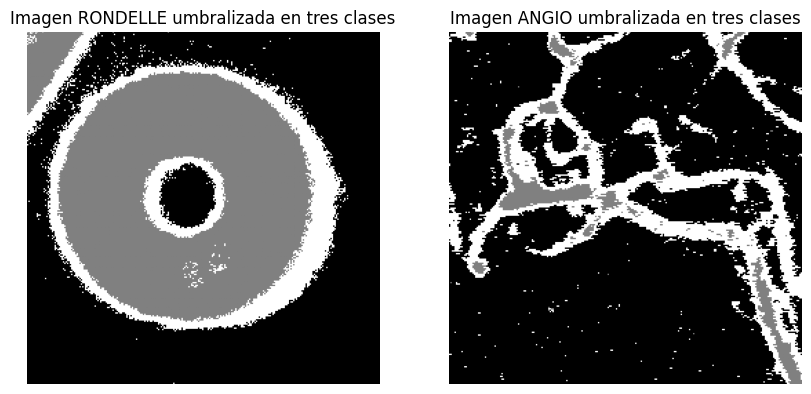

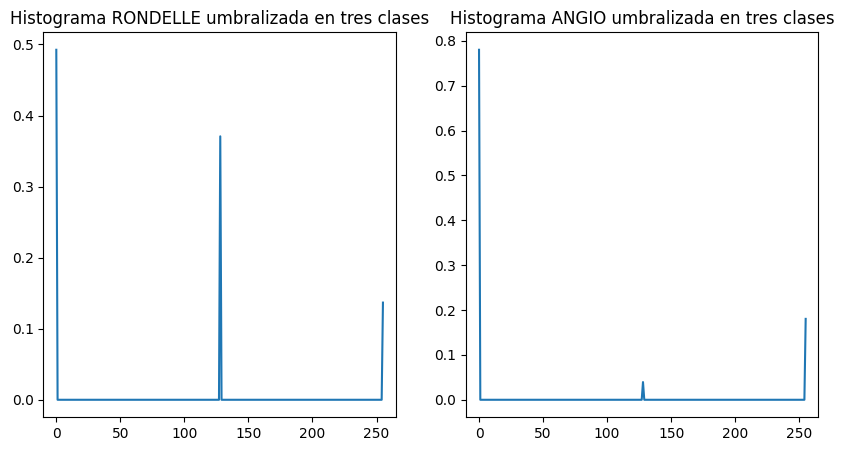

In [151]:
# aplicar umbralizaciones
rondelle_tres_clases = umbral_tres_clases(rondelle_image, 70, 140)
angio_tres_clases = umbral_tres_clases(angio_image, 70, 140)

# visualizar las imagenes
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(rondelle_tres_clases, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen RONDELLE umbralizada en tres clases")
plt.subplot(1,2,2)
plt.imshow(angio_tres_clases, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Imagen ANGIO umbralizada en tres clases")
plt.show()

# visualizar los histogramas
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
histogram_rondelle = calculate_histogram(rondelle_tres_clases, hist_title="Histograma RONDELLE umbralizada en tres clases", show=False)
plt.subplot(1,2,2)
histogram_angio = calculate_histogram(angio_tres_clases, hist_title="Histograma ANGIO umbralizada en tres clases", show=False)
plt.show()

- 5. Deduzca de estos ejemplos el rol y las condiciones de utilización de la umbralización doble. ¿Cómo es el comportamiento (ventajas y desventajas) con respecto a: conectividad, extracción de objetos de formas complejas o ramificadas y calidad de los contornos o fronteras de los objetos extraídos?


La umbralización doble permite clasificar pixeles dentro de un rango específico, mientras que en la umbralización simple solo se puede clasificar por encima o por debajo de un umbral. Esto hace que la umbralización doble combinada con la umbralización simple sea una técnica útil para segmentar imágenes con objetos que tienen diferentes niveles de intensidad, permitiendo su extracción. Esta técnica puede ser muy útil en condiciones donde los objetos de interés presentan intensidades claramente diferenciables entre ellos, pues es necesario escoger umbrales que faciliten dicha segmentación.

En cuanto a la conectividad de los objetos segmentados, esta técnica puede presentar limintaciones según los umbrales escogidos, pues píxeles pertenecientes a la misma estructura pueden quedar clasificados en clases diferentes, presentando desconexiones en objetos alargados o ramificados, como se puede observar en la imagen ANGIO.
Con respecto a la extracción de objetos con formas complejas, a pesar de que logra separar los objetos de las imágenes exploradas, puede resultar insuficiente si no se garantiza que los umbrales escogidos perservan la completa estructura del objeto que se quiere segmentar. En cuanto a la calidad de los contornos, esta técnica aporta una diferenciación abrupta entre clases, creando contornos poco suaves, pero muy bien diferenciados.

A pesar de las limitaciones mencionadas, es una técnica sencilla de aplicar que puede ser muy efectiva para la segmentación de diversos objetos.

---

## 6. Ejercicio de síntesis taller 2.

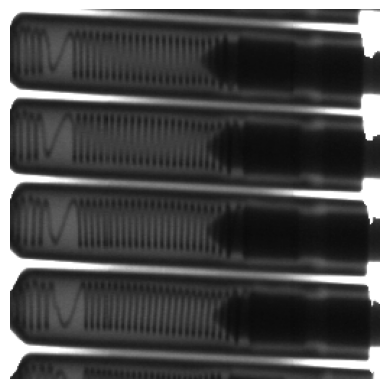

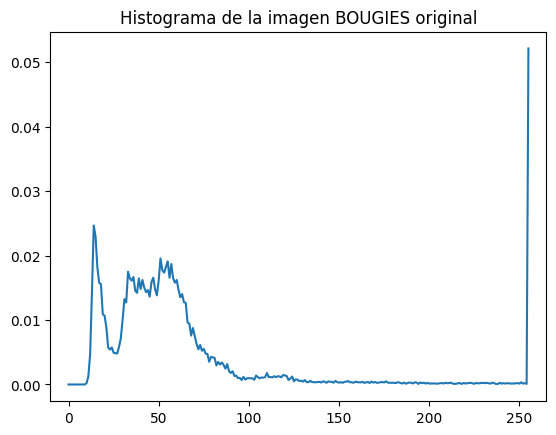

In [152]:
# cargar y visualizar la imagen y su histograma
bougies_image = read_and_show_image_gray_scale(path + 'BOUGIES.png')

bougies_histogram = calculate_histogram(bougies_image, hist_title="Histograma de la imagen BOUGIES original", show=True)

Buscamos hacer dos procedimientos:
1. Segmentar las bujías del fondo y pasar el fondo a negro.
2. Mejorar el contraste de las bujías y los objetos que tienen dentro.

Observando el histograma y la imagen notamos que el fondo de la imagen no solo toma colores blancos puros, sino que tiene cierto ruido. Para separar entonces el fondo, se puede **umbralizar** la imagen, tomando como umbral 50, de manera que todo pixel con valores por encima de 50 quedan en blanco y por debajo en negro, creando una especie de máscara binaria. Sin embargo, como queremos que el fondo quede de color negro, le aplicamos la operación NOT. A continuación se encuentra el resultado de la umbralización.

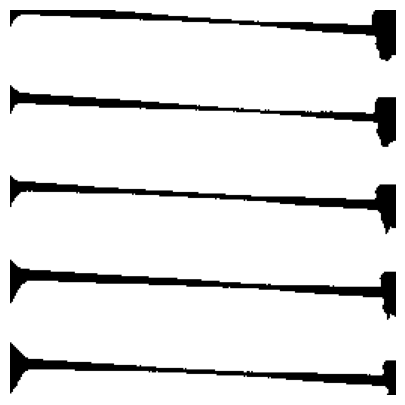

In [179]:
# umbralizar
_, thres_bougies = cv2.threshold(rescaled_img_bougies, 50, 255, cv2.THRESH_BINARY)
thres_bougies = cv2.bitwise_not(thres_bougies)

plt.figure(figsize=(10,5))
plt.imshow(thres_bougies, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Lo siguiente que vamos a hacer es juntar el fondo negro con las bujías haciendo uso de una operación AND.

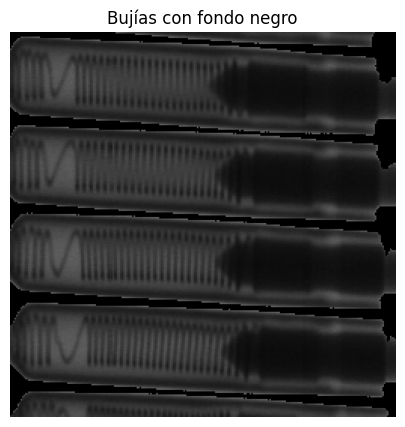

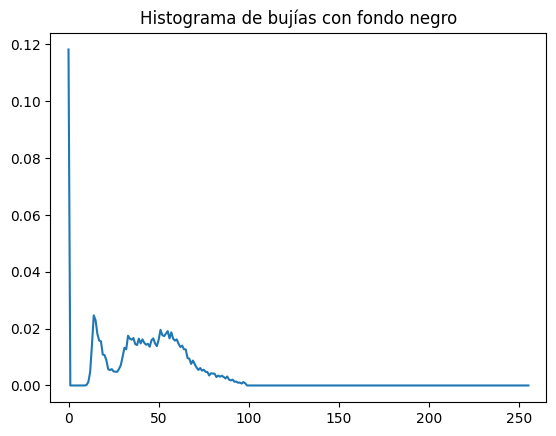

In [183]:
# bougies with black background
bougies_black_background = cv2.bitwise_and(bougies_image, thres_bougies)

plt.figure(figsize=(10,5))
plt.imshow(bougies_black_background, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title("Bujías con fondo negro")
plt.show()

histogram_black_background = calculate_histogram(bougies_black_background, hist_title="Histograma de bujías con fondo negro")


Ahora que tenemos una imagen donde la mayoría de píxeles toman tonos oscuros, podemos ecualizarla. Esto hace que el contraste mejore, y, al ser una función 1 a 1, los tonos negros serán todos mapeados a negro.

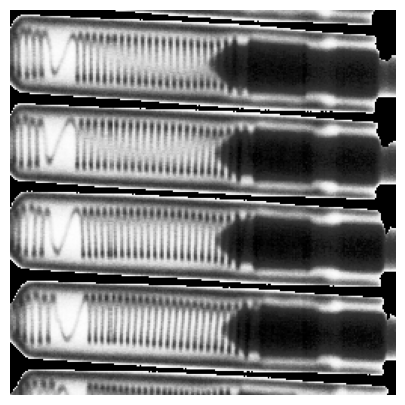

In [ ]:
# ecualizar
equ_bougies = cv2.equalizeHist(bougies_black_background)

plt.figure(figsize=(10,5))
plt.imshow(equ_bougies, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


De esta forma, obtuvimos un fondo negro y mejoramos el contraste de los objetos.